# Modeling (Im)Precision in Context

This notebook accompanies the case study in:

- Mühlenbernd, R., Solt, S., & Sauerland, U. (in press). *[Chapter title]*. In *[Edited Volume]*.

It reproduces the empirical analysis and probabilistic speaker model from:

- Mühlenbernd, R. & Solt, S. (2022). Modeling (im)precision in context. *Linguistics Vanguard*, 8(1), 113–127. https://doi.org/10.1515/lingvan-2022-0035

---

## Overview

How precisely do speakers communicate numerical information — and does context matter?

In Mühlenbernd & Solt (2022), we report a **production experiment** in which 499 participants reported the time of a witnessed accident. The key manipulations were **context** (police station vs. neighbor at a party) and **information state** (the time of the accident, displayed on a watch image). The central finding: speakers round off more in the neighbor context than in the police context. A probabilistic game-theoretic speaker model reproduces this pattern by fitting context-specific weights for the speaker goals of accuracy and hearer-oriented simplification.

**Notebook structure:**
1. Environment setup (local and Colab)
2. Data loading and cleaning
3. *(Optional)* Production Matrices
4. *(Optional)* Context effects of Rounding
5. *(Optional)* Motive analysis
6. Probabilistic speaker model

Sections marked *optional* reproduce the empirical analysis from the paper. They can be skipped if you are primarily interested in the model.

## 1. Environment Setup

Before anything else, the notebook needs to prepare its working environment.
Run the cell below to complete this setup — it only needs to be run once per session.

The cell does two things:

1. **Locates the repository.** The notebook can be run either on your own computer or in Google Colab (a free cloud environment). It detects which case applies and, if running in Colab, automatically downloads the project files so everything is in the right place.

2. **Loads the required tools.** It imports the Python libraries used throughout the notebook — for working with data, producing plots, and running statistical tests — as well as the analysis helper functions written specifically for this project.

In [1]:
# ── 1a. Detect environment and locate the repository ─────────────────────────
import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('imprecision-in-context'):
        !git clone https://github.com/muehlenbernd/imprecision-in-context.git
    os.chdir('imprecision-in-context/notebooks')
    print('Running in Colab — repository cloned.')
else:
    print('Running locally.')

# Make the helper modules in src/ importable
sys.path.insert(0, os.path.abspath('../src'))

# ── 1b. Import libraries and project helpers ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

from stats.analysis import (
    build_matrix, plot_response_matrices, plot_motives,
    chi2_context_test, chi2_per_state,
    plot_rounding_effect,
    STATE_LABELS, STATE_ORDER
)

# Set the global plot style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.dpi': 120
})

print('Environment ready.')

Running locally.
Environment ready.


## 2. Data Loading and Cleaning

The participant-level data is available at:
- Figshare: https://doi.org/10.6084/m9.figshare.21629531
- This repository: `data/raw/Participant_level_data_1_.xlsx`

The Excel file contains two sheets:
- `FillerStudyFullClass`: 499 participant-level rows
- `Description`: codebook for all columns

The first cell below loads the raw data. It reads the `FillerStudyFullClass` sheet from the Excel file — either from the local repository or, if running in Colab, directly from GitHub — and stores it in the dataframe `df_raw`.

In [2]:
GITHUB_URL = (
    'https://raw.githubusercontent.com/muehlenbernd/'
    'imprecision-in-context/main/data/raw/Participant_level_data_1_.xlsx'
)
LOCAL_PATH = '../data/raw/Participant_level_data_1_.xlsx'

data_source = LOCAL_PATH if os.path.exists(LOCAL_PATH) else GITHUB_URL
print(f'Loading from: {data_source}')

df_raw = pd.read_excel(data_source, sheet_name='FillerStudyFullClass', header=1)
print(f'Total participants loaded: {len(df_raw)}')

Loading from: ../data/raw/Participant_level_data_1_.xlsx
Total participants loaded: 499


Let's take a look at the first 10 rows of the data with respect to the production task. Additional columns relating to a follow-up task are not shown here for simplicity.

In [3]:
df_raw.head(10).iloc[:, :9]

,id,session,sid,context,state,answer,stateC,answerC,appxC
0,1005,1,5,neighbor,at 8:32,08:37am,2,-1,0
1,1008,1,8,police,at 8:30,8.30 am,0,0,0
2,1009,1,9,police,at 8:28,around half 8,2,10,around
3,1010,1,10,police,at 8:34,Just before twenty five to nine,4,15,just before/after
4,1011,1,11,police,8:26-8:34,25 past to 25 to 8,8,9,0
5,1012,1,12,neighbor,at 8:30,08:30,0,0,0
6,1013,1,13,neighbor,at 8:32,half 8,2,0,0
7,1015,1,15,neighbor,8:26-8:34,"around 8.30 am, give or take 4 minutes.",8,18,around
8,1016,1,16,police,at 8:30,8.30am,0,0,0
9,1018,1,18,police,at 8:34,around 8:35,4,15,around


The follwoing table descibes the categories and coding:

| Column | Description |
|--------|-------------|
| `id` | unique id of the participant |
| `session` | id of the session: `1` or `2` |
| `sid` | participant id within the session |
| `context` | `police` or `neighbor` |
| `state` | Information state: `at 8:25`, `at 8:26`, `at 8:27`, ... `at 8:35`, `8:26-8:34` |
| `answer` | free text answer given by the participant |
| `stateC` | Information state category: numbers 0-5 repesent how many minutes off round, 8 represents approximate range `8:26–8:34`|
| `answerC` | Answer category: more details in the report, `-1` = excluded (miscoded clock) |
| `appxC` | Approximator term used (e.g. *around*, *about*; `0` = none) |

Now let's remove entries for participants who misread the clock and output the excluded and remaining data points, as well as the number of data points per context.

In [4]:
# Exclude participants whose clock readings could not be coded (answerC == -1)
n_excluded = (df_raw['answerC'] == -1).sum()
df = df_raw[df_raw['answerC'] != -1].copy()

print(f'Excluded data points: {n_excluded}')
print(f'Remaining data points: {len(df)}')
print()
print(f'Data points per', df['context'].value_counts().to_string())

Excluded data points: 24
Remaining data points: 475

Data points per context
neighbor    244
police      231


Note: For further analysis and model application, the information states were labeled according to the following scheme:

| Label | Original information states |
|--------|-------------|
| $s_{30}$ | `8:30` |
| $s_{30\pm1}$ |  `8:29`,  `8:31` |
| $s_{30\pm2}$ |  `8:28`,  `8:32` |
| $s_{30\pm3}$ |  `8:27`,  `8:33` |
| $s_{30\pm4}$ |  `8:26`,  `8:34` |
| $s_{30\pm5}$ |  `8:25`,  `8:35` |
| $s_{In}$ |  `8:26-8:34` |

Similarly, the answer categories were labeled according to the following scheme:

| Label | Type of participant answer |
|--------|-------------|
| $v_{a30}$ | `around 8:30`, `about 8:30`, etc. |
| $v_{30}$ | `at 8:30`, `exactly at  8:30`, etc. |
| $v_{30\pm1}$ |  `at 8:29`,  `at 8:31`, etc. |
| $v_{30\pm2}$ |  `at 8:28`,  `at 8:32`, etc. |
| $v_{30\pm3}$ |  `at 8:27`,  `at 8:33`, etc. |
| $v_{30\pm4}$ |  `at 8:26`,  `at 8:34`, etc. |
| $v_{30\pm5}$ |  `at 8:25`,  `at 8:35`, etc. |
| $v_{a30\pm5}$ |  `around 8:25`,  `about 8:35`, etc. |
| $v_{In}$ |  `between 8:25 and 8:35` |

## 3. Production Matrices *(optional)*

The following code produces the production matrices, one for the police context and one for the neighbor context. Each matrix has rows = information states, columns = response categories, cells = proportion of participants choosing that response. These are the normalized matrices shown in **Figure 2** of the paper.

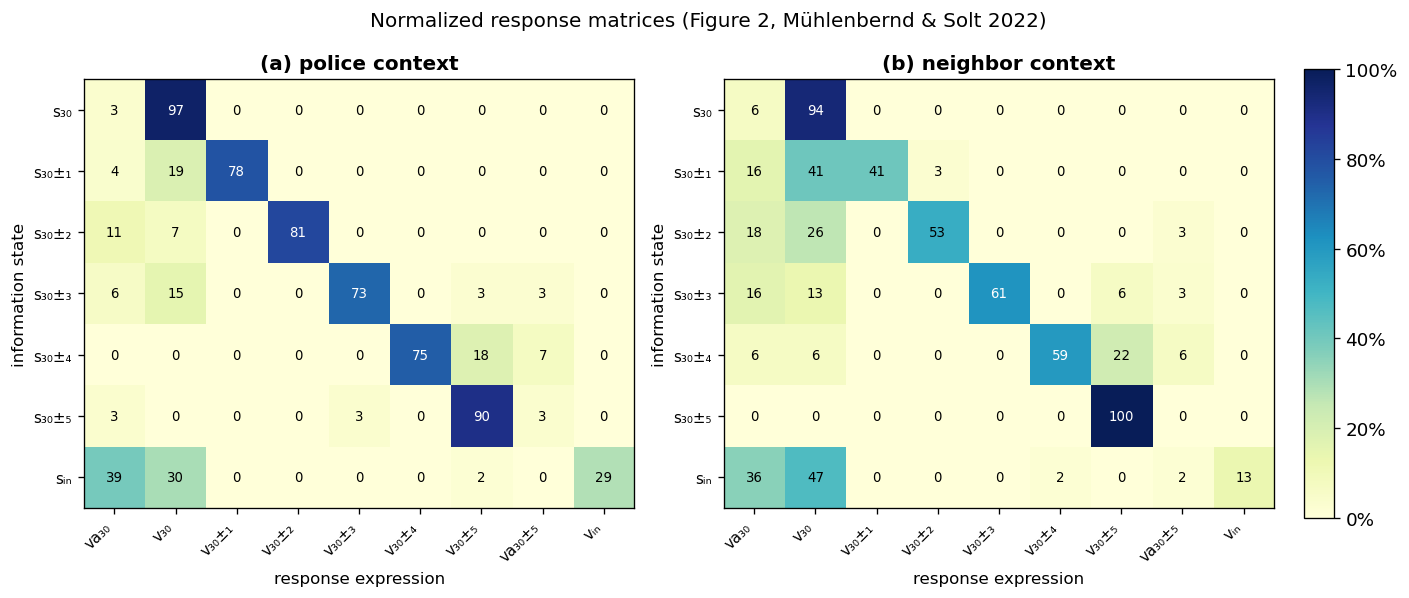

In [5]:
matrix_police   = build_matrix(df, 'police')
matrix_neighbor = build_matrix(df, 'neighbor')

plot_response_matrices(
    matrix_police, matrix_neighbor,
    title='Normalized response matrices (Figure 2, Mühlenbernd & Solt 2022)',
    save_path='../figures/figure2_response_matrices.png'
)

## 4. Context Effects of Rounding *(optional)*

We test whether the distribution of round responses differs significantly between contexts. The paper reports the following significant effect:
- Non-round precise states (s₃₀±₁ through s₃₀±₄) pooled: χ²=13.198, *p*<0.001

The following code reproduces the chi text and displays a bar plot of round vs non-round answers across contexts for non-round information states:


Non-round precise states (s₃₀±₁ to s₃₀±₄) — binary round/non-round:
  χ²(1) = 12.241, p = 0.0005


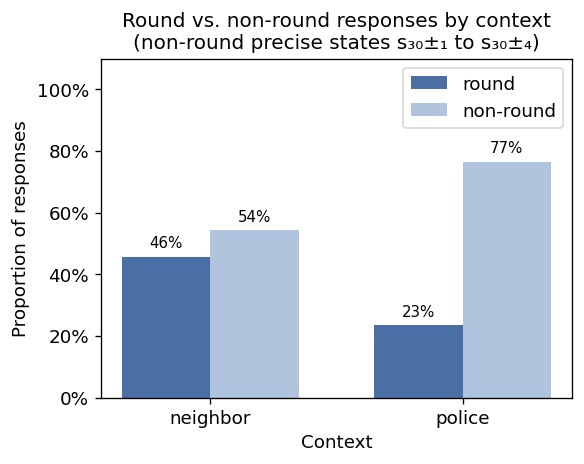

In [6]:
# Round vs. non-round binary test (non-round precise states s₃₀±₁ to s₃₀±₄)
# Round responses: bare 8:30 (0), around 8:30 (10), bare 8:25/8:35 (5), around 8:25/8:35 (15)
ROUND_CODES = {0, 5, 10, 15}

sub = df[df['stateC'].isin([1, 2, 3, 4])].copy()
sub['rounded'] = sub['answerC'].isin(ROUND_CODES).map({True: 'round', False: 'non-round'})

ct = pd.crosstab(sub['context'], sub['rounded'])

chi2, p, dof, _ = chi2_contingency(ct)
print(f'Non-round precise states (s₃₀±₁ to s₃₀±₄) — binary round/non-round:')
print(f'  χ²({dof}) = {chi2:.3f}, p = {p:.4f}')

plot_rounding_effect(ct, save_path='../figures/figure_rounding_by_context.png')

## 5. Motive Analysis *(optional)*

After answering the main question, participants were asked to justify their choice. Responses were coded into 11 categories (plus *other*); multiple categories could apply.

The motive profiles differ systematically by context: accuracy concerns dominate in the police context, while ease and habit dominate in the neighbor context. This provides independent behavioral evidence for the model's core assumption — that speakers weight the goals of accuracy (*w*ₐ) and hearer-oriented simplification (*w*ᵣ) differently depending on the situation.

It also raises an interesting question for LLM evaluation: when prompted to justify a precision choice, do language models produce motive profiles that resemble human speakers?

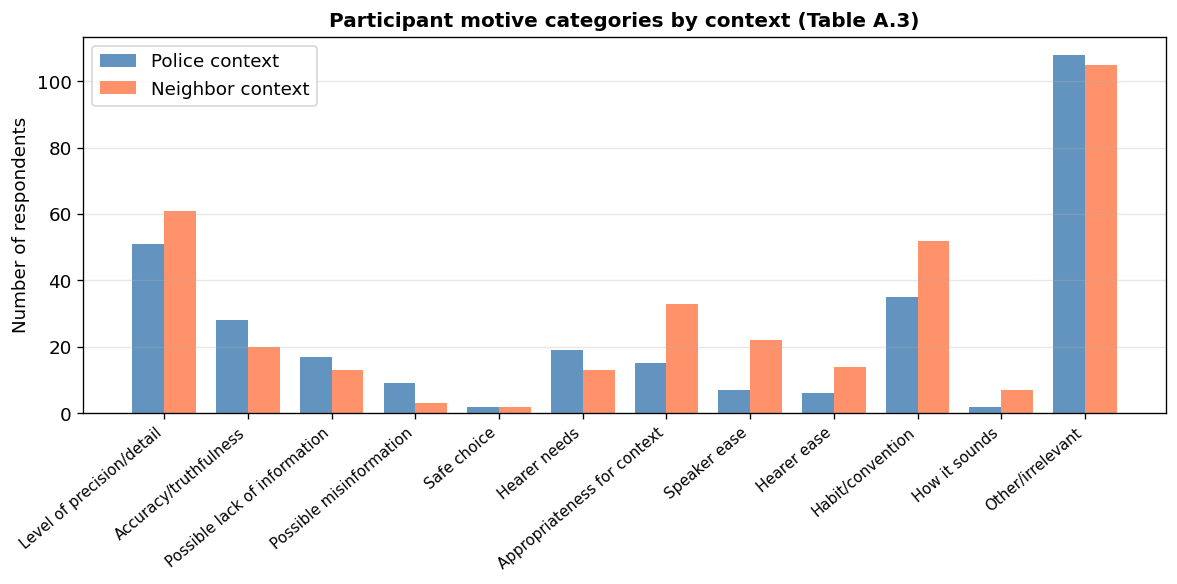

,police,neighbor
Level of precision/detail,51,61
Accuracy/truthfulness,28,20
Possible lack of information,17,13
Possible misinformation,9,3
Safe choice,2,2
Hearer needs,19,13
Appropriateness for context,15,33
Speaker ease,7,22
Hearer ease,6,14
Habit/convention,35,52


In [7]:
motive_df = plot_motives(df, save_path='../figures/figure_motives.png')
motive_df

## 6. The Imprecision Model

The Imprecision Model predicts the probability $P_S(v \mid s)$ that a pragmatic speaker uses utterance $v$ given information state $s$. Speaker choice follows a softmax over a total utility $U_{tot}$:

$$P_S(v \mid s) \propto \exp(\lambda \cdot U_{tot}(v, s, P_H, w))$$

The total utility decomposes into four components:

$$U_{tot}(v, s, P_H, w) = U_{inf}(v, s, P_H) + w_R \cdot U_{rnd}(v) + w_A \cdot U_{acc}(v, s) - C(v)$$

| Component | Symbol | Role |
|-----------|--------|------|
| Informational utility | $U_{inf}$ | How informative $v$ is for the hearer given $s$ |
| Roundness utility | $U_{rnd}$ | Reward for hearer-friendly round numbers (weighted by $w_R$) |
| Accuracy utility | $U_{acc}$ | Reward for utterances likely to be true given $s$ (weighted by $w_A$) |
| Utterance cost | $C(v)$ | Penalty for longer/more complex forms |

The inference pipeline runs in three steps:
1. **P_S0** — literal speaker: distributes probability uniformly over utterances whose denotation covers $s$
2. **P_H** — Bayesian hearer: updates belief over states given the literal speaker
3. **P_S** — pragmatic speaker: applies softmax over $U_{tot}$ given $P_H$

By fitting $w_R$ and $w_A$ separately for the police and neighbor contexts, the model reproduces the empirical matrices with Pearson $r = 0.985$ (Section 4 of the paper).

### 7.1 Model imports

In [ ]:
from model import ImprecisionModel, build_imprecision_game
from model.experiment import (
    LAM, ALPHA,
    W_R_POLICE, W_A_POLICE,
    W_R_NEIGHBOR, W_A_NEIGHBOR,
    EMPIRICAL_POLICE, EMPIRICAL_NEIGHBOR,
    STATE_LABELS as MODEL_STATE_LABELS,
    RESPONSE_LABELS
)
from model.utils import select_submatrix, normalize_rows

print('Model imports OK.')
print(f'Default parameters: λ={LAM}, α={ALPHA}')
print(f'Optimal weights — police:   w_R={W_R_POLICE}, w_A={W_A_POLICE}')
print(f'Optimal weights — neighbor: w_R={W_R_NEIGHBOR}, w_A={W_A_NEIGHBOR}')

### 7.2 Setting up the game

The `build_imprecision_game()` function constructs the signaling game $G = (S, V, Pr, D, C, \pi)$ for this experiment. It defines:
- **S**: 12 information states (11 precise singleton states + 1 approximate range state $s_{In}$)
- **V**: 15 utterances (bare expressions, approximator-modified, and interval)
- **D**: denotation function — literal denotation for bare expressions, broader ranges for approximators
- **Pr**: uniform prior over S
- **C**: small cost (0.1) for complex forms (approximators and intervals), 0 for bare expressions
- **π**: Nosofsky similarity-based payoff matrix, controlled by $\alpha$

In [ ]:
game = build_imprecision_game(alpha=ALPHA)

print(game)
print()
print('Information states S:')
for i, s in enumerate(game.S):
    print(f'  s[{i:2d}] = {s}')
print()
print('Utterances V:', game.V)
print()
print('Costs C:', game.C)

### 7.3 Instantiating the model with dummy weights

To illustrate the model structure, we first instantiate it with dummy weights $w_R = 0.5$ and $w_A = 0.5$ — equal weighting of roundness and accuracy pressure. This is not the optimal fit; optimal weights per context are derived in Section 7.5.

We then inspect a single probability: $P_S(v_{30} \mid s_{30\pm2})$ — the probability that a speaker who knows the time is 8:28 or 8:32 rounds to the bare value "8:30".

In [ ]:
# Instantiate with dummy weights
model_dummy = ImprecisionModel(
    game,
    w_R=0.5,
    w_A=0.5,
    lam=LAM,
    roundness_hierarchy=game.roundness_hierarchy
)

print(f'Model parameters: w_R={model_dummy.w_R}, w_A={model_dummy.w_A}, λ={model_dummy.lam}')
print()

# Run the inference pipeline
S0 = model_dummy.P_S0()   # literal speaker
H  = model_dummy.P_H(S0)  # Bayesian hearer
S1 = model_dummy.P_S(H)   # pragmatic speaker

# Inspect a single probability: P_S(v30 | s30±2)
# s30±2 = state [28] (8:28) — index 2 in S
# v30   = utterance 'v30' (bare "8:30")
s_query = game.S[2]   # [28], i.e. 8:28
v_query = 'v30'       # bare "8:30"

# The raw softmax matrix is not yet row-normalized; normalize to get probabilities
row_idx = [game.S.index(s_query)]
raw_row = S1.X[row_idx[0]]
row_sum = sum(raw_row)
prob = S1.get_entry(s_query, v_query) / row_sum

print(f'Query: P_S(v30 | s30±2 = {s_query})')
print(f'  → {prob:.4f}  ({prob*100:.1f}%)')
print()
print('Interpretation: with equal roundness and accuracy pressure,')
print(f'a speaker who knows the time is 8:28 rounds up to "8:30"')
print(f'with probability {prob*100:.1f}%.')

### 7.4 Comparing utility components

To build intuition for how the utility function works, we inspect the individual utility values for a selection of utterances given state $s_{30\pm2}$ = [28] (8:28 or 8:32).

Expected pattern:
- $U_{acc}$ should be highest for the exact bare value matching the state (e.g. `v28`)
- $U_{rnd}$ should be highest for the round value `v30` and approximator `vA30`
- $U_{inf}$ reflects both, mediated by the hearer's interpretation

In [ ]:
import pandas as pd

s = game.S[2]  # s30±2 = [28]
selected_V = ['v28', 'v29', 'v30', 'v31', 'v32', 'vA30', 'vIn']

rows = []
for v in selected_V:
    rows.append({
        'v': v,
        'U_inf': round(model_dummy.U_inf(v, s, H), 3),
        'U_rnd': round(model_dummy.U_rnd(v), 3),
        'U_acc': round(model_dummy.U_acc(v, s), 3),
        'C(v)':  round(game.cost(v), 3),
        'U_tot': round(model_dummy.U_tot(v, s, H), 3),
    })

df_utils = pd.DataFrame(rows).set_index('v')
print(f'Utility components for state s30±2 = {s}  (w_R=0.5, w_A=0.5):')
df_utils

### 7.5 Running the model with paper parameters

We now run the model with the optimal weight parameters reported in the paper (Section 4) for each context, and compare the model's reconstruction matrix against the empirical data.

The full model output is a 12×15 matrix (12 states × 15 utterances). To compare with Figure 2, we reduce it to a 7×9 matrix by selecting the 7 state categories and 9 response categories used in the paper.

In [ ]:
# Row indices in the full S1 matrix corresponding to the 7 paper categories
# s30=5, s30±1=4, s30±2=3, s30±3=2, s30±4=1, s30±5=0, sIn=11
ROW_IDX = [5, 4, 3, 2, 1, 0, 11]

# Column indices for the 9 paper response categories
# v30=5, v30±1=4, v30±2=3, v30±3=2, v30±4=1, v30±5=0, vIn=11, vA30=12, vA25=13
COL_IDX = [5, 4, 3, 2, 1, 0, 11, 12, 13]


def run_model_for_context(w_R, w_A, label):
    """Run the Imprecision Model and return the reduced 7x9 matrix."""
    model = ImprecisionModel(
        game, w_R=w_R, w_A=w_A, lam=LAM,
        roundness_hierarchy=game.roundness_hierarchy
    )
    S1 = model.run()
    sub  = select_submatrix(S1.X, ROW_IDX, COL_IDX)
    norm = normalize_rows(sub)
    print(f'Model reconstruction — {label} (w_R={w_R}, w_A={w_A}):')
    return pd.DataFrame(
        [[int(round(v * 100)) for v in row] for row in norm],
        index=MODEL_STATE_LABELS,
        columns=RESPONSE_LABELS
    )


model_police   = run_model_for_context(W_R_POLICE,   W_A_POLICE,   'police context')
model_neighbor = run_model_for_context(W_R_NEIGHBOR, W_A_NEIGHBOR, 'neighbor context')

print()
print('Police context reconstruction:')
display(model_police)
print()
print('Neighbor context reconstruction:')
display(model_neighbor)

### 7.6 Comparing model and empirical matrices

A direct side-by-side comparison of the empirical data (from Section 4) and the model reconstruction, displayed as heatmaps matching Figure 4 in the paper.

In [ ]:
import numpy as np

cmap = plt.cm.YlGnBu

emp_police   = np.array(EMPIRICAL_POLICE)
emp_neighbor = np.array(EMPIRICAL_NEIGHBOR)
mod_police   = model_police.values / 100
mod_neighbor = model_neighbor.values / 100

# Layout: 2 rows x 2 cols
# Row 0 (top):    empirical police  | model police
# Row 1 (bottom): empirical neighbor | model neighbor

cell_size = 0.55
n_rows_m, n_cols_m = 7, 9
ax_w = n_cols_m * cell_size
ax_h = n_rows_m * cell_size

gap_col = 0.5
gap_row = 0.9
left_pad  = 0.8
right_pad = 1.0
top_pad   = 0.5
bot_pad   = 0.9

fig_w = left_pad + 2*ax_w + gap_col + right_pad
fig_h = top_pad  + 2*ax_h + gap_row + bot_pad

fig = plt.figure(figsize=(fig_w, fig_h))

aw = ax_w / fig_w
ah = ax_h / fig_h
gw = gap_col / fig_w
gh = gap_row / fig_h
lp = left_pad / fig_w
bp = bot_pad / fig_h

b_top = bp + ah + gh
b_bot = bp

panels = [
    (lp,       b_top, emp_police,   '(a) empirical — police'),
    (lp+aw+gw, b_top, mod_police,   '(b) model — police'),
    (lp,       b_bot, emp_neighbor, '(c) empirical — neighbor'),
    (lp+aw+gw, b_bot, mod_neighbor, '(d) model — neighbor'),
]

last_im = None
for left, bottom, data, title in panels:
    ax = fig.add_axes([left, bottom, aw, ah])
    im = ax.imshow(data, aspect='equal', cmap=cmap, vmin=0, vmax=1)
    last_im = im
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            pct = int(round(data[i, j] * 100))
            if pct > 0:
                color = 'white' if data[i, j] > 0.55 else 'black'
                ax.text(j, i, str(pct), ha='center', va='center',
                        fontsize=8, color=color)
    ax.set_xticks(range(n_cols_m))
    ax.set_xticklabels(RESPONSE_LABELS, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n_rows_m))
    ax.set_yticklabels(MODEL_STATE_LABELS, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')

# Colorbar spanning both rows
cbar_left   = (left_pad + 2*ax_w + gap_col + 0.15) / fig_w
cbar_bottom = b_bot
cbar_height = ah*2 + gh
cax = fig.add_axes([cbar_left, cbar_bottom, 0.2/fig_w, cbar_height])
cbar = fig.colorbar(last_im, cax=cax)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

fig.suptitle('Empirical vs. model reconstruction (Figure 4, Mühlenbernd & Solt 2022)',
             fontsize=11, y=0.99)
plt.savefig('../figures/figure4_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### 7.7 What the weight parameters capture

The key result from the paper is that the optimal weight parameters differ systematically between contexts:

| Context | $w_R$ (roundness) | $w_A$ (accuracy) | Interpretation |
|---------|-------------------|------------------|----------------|
| Police  | 0.46 | 0.22 | Moderate rounding pressure; higher accuracy concern |
| Neighbor | 0.66 | 0.02 | Strong rounding pressure; accuracy nearly irrelevant |

This is consistent with participants' own reported motives (Section 6 above): accuracy and misinformation concerns are more prominent in the police context, while ease and habit dominate in the neighbor context.

The next step — to be developed in a follow-up study — is to apply the same stimuli to LLMs and ask: do language models show a similar context-driven shift in $w_R$ and $w_A$? Or do they treat both contexts as equivalent?

---

## Citation

If you use this data or code, please cite:

```bibtex
@article{muhlenbernd_solt_2022,
  author  = {Mühlenbernd, Roland and Solt, Stephanie},
  title   = {Modeling (im)precision in context},
  journal = {Linguistics Vanguard},
  year    = {2022},
  volume  = {8},
  number  = {1},
  pages   = {113--127},
  doi     = {10.1515/lingvan-2022-0035}
}
```